# Imports

In [1]:
from pathlib import Path

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Functions

In [2]:
def plot_signal(data: pd.DataFrame) -> tuple[plt.figure, plt.axes]:
    fig, ax = plt.subplots(figsize=(15,8))
    ax.plot(df)

    ax.grid(visible=True)
    ax.tick_params(axis='both', labelsize=14)

    ax.set_xlabel("time (a.u.)", fontsize=18)
    ax.set_ylabel("amplitude ($V$)", fontsize=18)
    
    return fig, ax

In [3]:
# Prep Steps
PARQ_PATH = Path("../sample_datasets/20220824_CERC_background/raw_data/parquet/20220824-0001.parquet")

In [17]:
# Loading Steps
start = time.perf_counter()
df = pd.read_parquet(PARQ_PATH)

df.columns = df.columns.astype('int16')

load_parquet_time = time.perf_counter() - start
num_initial_signals = df.shape[0]

print(
    f"\x1b[1;36m{num_initial_signals}\x1b[0m signals loaded in "
    f"\x1b[1;32m{(load_parquet_time)*1000:.2f} ms\x1b[0m."
)

10000 signals loaded in 54.80 ms.


In [18]:
# Drop any signals that have missing or infinite values
start = time.perf_counter()

df = df.replace([np.inf, -np.inf], np.nan).dropna(how='any')

remove_missing_time = time.perf_counter() - start
num_missing_signals = num_initial_signals - df.shape[0]

print(
    f"Removed \x1b[1;31m{num_missing_signals}\x1b[0m signals "
    f"with missing or infinite values. "
    f"[\x1b[1;32m{(remove_missing_time)*1000:.2f} ms\x1b[0m]"
)

Removed 558 signals with missing or infinite values. [41.28 ms]


In [19]:
df = df.T
df.head()

,b0001s00001,b0001s00002,b0001s00003,b0001s00004,b0001s00006,b0001s00007,b0001s00008,b0001s00009,b0001s00010,b0001s00011,...,b0001s09990,b0001s09991,b0001s09992,b0001s09993,b0001s09994,b0001s09995,b0001s09996,b0001s09997,b0001s09999,b0001s10000
0,0.955229,0.954711,0.956847,0.957884,0.956847,0.953642,0.956298,0.955229,0.956847,0.955779,...,0.954711,0.954711,0.952605,0.956298,0.957366,0.955229,0.955779,0.954192,0.956847,0.958953
1,0.954192,0.954192,0.955229,0.956298,0.954711,0.958434,0.950987,0.954711,0.958434,0.955779,...,0.953642,0.956847,0.954711,0.954192,0.956847,0.953642,0.954192,0.955779,0.956298,0.954192
2,0.957366,0.950987,0.957884,0.955779,0.956298,0.954192,0.956298,0.958434,0.958434,0.955779,...,0.955779,0.957366,0.953642,0.953124,0.956298,0.952605,0.952605,0.958434,0.951537,0.955779
3,0.954192,0.953642,0.953642,0.954192,0.956847,0.957366,0.956847,0.952605,0.955229,0.953642,...,0.956847,0.957884,0.955229,0.956298,0.955229,0.952605,0.953642,0.956847,0.953642,0.954711
4,0.953642,0.953642,0.957366,0.956847,0.956847,0.956298,0.956298,0.954711,0.953124,0.957884,...,0.954192,0.953124,0.955779,0.951537,0.955779,0.952605,0.954192,0.953124,0.953124,0.954711


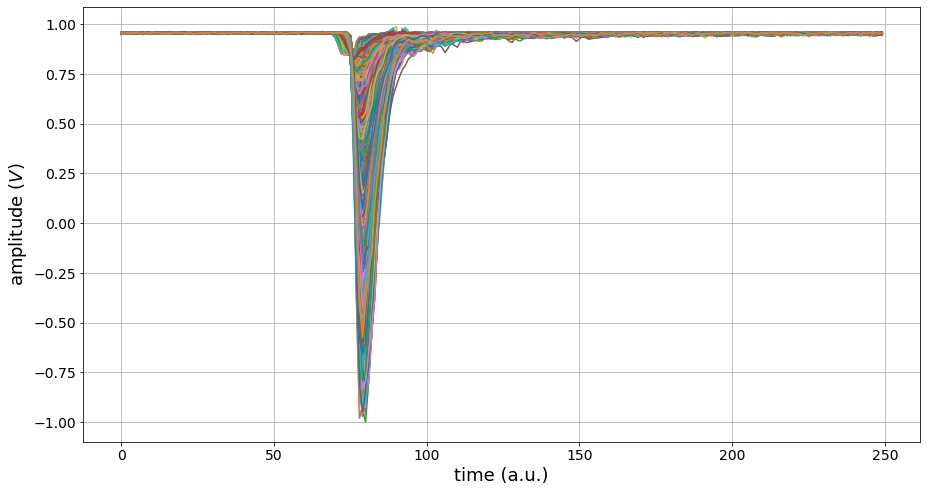

In [14]:
plot_signal(df)
plt.show()

In [20]:
# Adjusting Steps

DC_OFFSET = 1.9  # Volts
df = df - DC_OFFSET

# df = df * -1

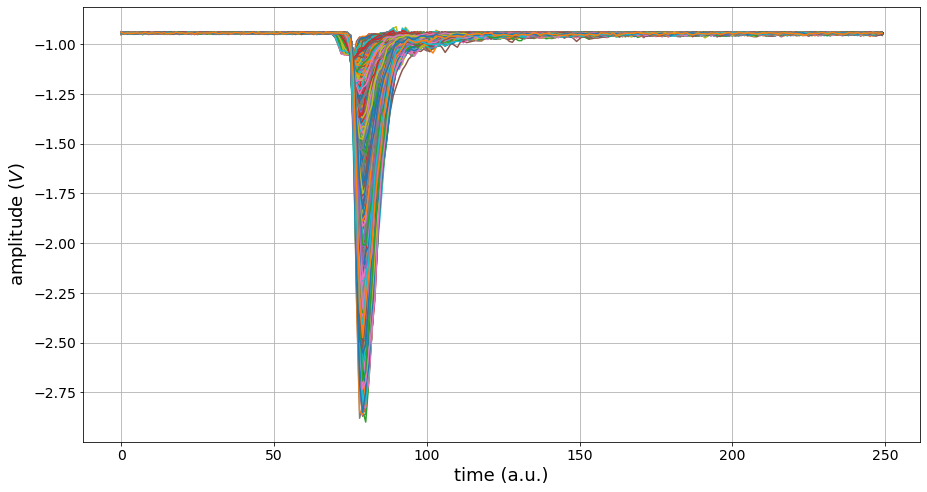

In [21]:
plot_signal(df)
plt.show()

In [ ]:
df = 

# Appendix: Time Analysis

In [ ]:
DC_OFFSET = 1.9

def TA_parq_loading()

In [ ]:
%%timeit
df = pd.read_parquet(PARQ_PATH)
df.columns = df.columns.astype('int16')

df = df - DC_OFFSET
df *= -1

In [ ]:
%%timeit
df = pd.read_parquet(PARQ_PATH)
df.columns = df.columns.astype('int16')
df = df.T

df = df - DC_OFFSET
df *= -1